In [ ]:
# 1. Install the specialized astronomy tool we need
!pip install lightkurve

# 2. Import our tools
import lightkurve as lk
from astroquery.mast import Catalogs
from google.colab import drive

# 3. Connect to your Google Drive to save our data later
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import lightkurve as lk
from astroquery.mast import Catalogs

print("1. Searching the sky...")
tic_results = Catalogs.query_region("65.0 -60.0", radius=1.0, catalog="Tic")
tic_df = tic_results.to_pandas()
good_stars_df = tic_df[(tic_df['Tmag'] >= 8.0) & (tic_df['Tmag'] <= 12.0)]

# Grab our 3 test stars
test_stars = good_stars_df['ID'].head(3).tolist()
print(f"Our Test Batch TIC IDs: {test_stars}\n")

print("2. Finding Light Curves safely...")
successful_searches = []

# Loop through each star one by one
for star_id in test_stars:
    target_name = f"TIC {star_id}"
    print(f"Searching for {target_name}...")

    # The try block attempts the risky server connection
    try:
        search = lk.search_lightcurve(target_name, mission="TESS", sector=1, author="SPOC")
        if len(search) > 0:
            successful_searches.append(search)
            print(f"  -> Success! Found {len(search)} files.")
        else:
            print("  -> No data found for this star.")

    # The except block catches any errors so the loop keeps going!
    except Exception as e:
        print(f"  -> Server error skipped! Moving on...")

print(f"\nFinished! Found data for {len(successful_searches)} stars.")

1. Searching the sky...
Our Test Batch TIC IDs: ['38633093', '396694701', '38633112']

2. Finding Light Curves safely...
Searching for TIC 38633093...
  -> No data found for this star.
Searching for TIC 396694701...
  -> No data found for this star.
Searching for TIC 38633112...
  -> Success! Found 1 files.

Finished! Found data for 1 stars.


In [ ]:
import os
import time
import numpy as np
import lightkurve as lk
from astroquery.mast import Catalogs

# 📁 Save directory in Google Drive
save_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
os.makedirs(save_dir, exist_ok=True)

print("Searching MAST catalog for stars...")

# 🔄 Retry settings for network requests
max_retries = 3
tic_results = None

# 1. Catalog Search with Retries
for attempt in range(max_retries):
    try:
        tic_results = Catalogs.query_region("65.0 -60.0", radius=1.0, catalog="Tic")
        print(" Connected! Successfully retrieved star catalog.")
        break
    except Exception as e:
        print(f" Attempt {attempt + 1} failed for catalog search. Retrying in 3 seconds...")
        time.sleep(3)

if tic_results is not None:
    # Filter for stars with TESS magnitude between 8.0 and 12.0
    tic_df = tic_results.to_pandas()
    good_stars_df = tic_df[(tic_df['Tmag'] >= 8.0) & (tic_df['Tmag'] <= 12.0)]

    # Select test batch of 3 stars
    test_stars = good_stars_df['ID'].head(3).tolist()
    print(f"Target TIC IDs: {test_stars}\n")

    # 📥 2. Loop with Download Retries
    for star_id in test_stars:
        target_name = f"TIC {star_id}"
        file_path = os.path.join(save_dir, f"TIC_{star_id}.npz")

        print(f"Processing {target_name}...")
        try:
            search = lk.search_lightcurve(target_name, mission="TESS", sector=1, author="SPOC")

            if len(search) > 0:
                # Retry loop specifically for downloading
                lc = None
                for dl_attempt in range(max_retries):
                    try:
                        lc = search.download()
                        break
                    except Exception as dl_err:
                        print(f"   Download attempt {dl_attempt + 1} failed. Retrying in 2 seconds...")
                        time.sleep(2)

                if lc is not None:
                    lc_clean = lc.remove_nans()
                    time_array = lc_clean.time.value
                    flux_array = lc_clean.pdcsap_flux.value

                    np.savez_compressed(file_path, time=time_array, flux=flux_array)
                    print(f"   Saved {len(time_array)} data points to Drive!")
                else:
                    print("   Could not download light curve after multiple retries.")
            else:
                print("   No SPOC data found for Sector 1.")

        except Exception as e:
            print(f"   Error searching star: {e}")

    print("\n Phase 1 Test Complete!")

Searching MAST catalog for stars...
 Attempt 1 failed for catalog search. Retrying in 3 seconds...
 Connected! Successfully retrieved star catalog.
Target TIC IDs: ['38633093', '396694701', '38633112']

Processing TIC 38633093...
   No SPOC data found for Sector 1.
Processing TIC 396694701...
   No SPOC data found for Sector 1.
Processing TIC 38633112...
   Saved 18277 data points to Drive!

 Phase 1 Test Complete!


In [ ]:
import os
import time
import numpy as np
import lightkurve as lk
from astroquery.mast import Catalogs
from tqdm.notebook import tqdm

# 📁 Save directory in Google Drive
save_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
os.makedirs(save_dir, exist_ok=True)

# 🎯 Set desired batch size (e.g., 100 stars)
BATCH_SIZE = 100

print("Searching MAST catalog for stars...")

# 🔄 Retry settings for catalog query
max_retries = 3
tic_results = None

for attempt in range(max_retries):
    try:
        tic_results = Catalogs.query_region("65.0 -60.0", radius=1.0, catalog="Tic")
        print(" Connected! Successfully retrieved star catalog.")
        break
    except Exception as e:
        print(f" Attempt {attempt + 1} failed for catalog search. Retrying in 3 seconds...")
        time.sleep(3)

if tic_results is not None:
    # Filter for stars with TESS magnitude between 8.0 and 12.0
    tic_df = tic_results.to_pandas()
    good_stars_df = tic_df[(tic_df['Tmag'] >= 8.0) & (tic_df['Tmag'] <= 12.0)]

    # Select batch of stars
    target_stars = good_stars_df['ID'].head(BATCH_SIZE).tolist()
    print(f"Targeting {len(target_stars)} stars for download.\n")

    saved_count = 0
    skipped_count = 0

    # 📥 Loop through batch with progress bar
    for star_id in tqdm(target_stars, desc="Downloading Light Curves"):
        target_name = f"TIC {star_id}"
        file_path = os.path.join(save_dir, f"TIC_{star_id}.npz")

        # IDEMPOTENCY: Skip if file already exists in Drive
        if os.path.exists(file_path):
            skipped_count += 1
            continue

        try:
            search = lk.search_lightcurve(target_name, mission="TESS", sector=1, author="SPOC")

            if len(search) > 0:
                lc = None
                for dl_attempt in range(max_retries):
                    try:
                        lc = search.download()
                        break
                    except Exception:
                        time.sleep(2)

                if lc is not None:
                    lc_clean = lc.remove_nans()
                    time_array = lc_clean.time.value
                    flux_array = lc_clean.pdcsap_flux.value

                    np.savez_compressed(file_path, time=time_array, flux=flux_array)
                    saved_count += 1

        except Exception as e:
            # Continue gracefully on individual star errors
            pass

    print(f"\n--- Batch Run Summary ---")
    print(f" New light curves saved: {saved_count}")
    print(f" Skipped (already downloaded): {skipped_count}")
    print(f" Total files in target set: {len(target_stars)}")

Searching MAST catalog for stars...


 Connected! Successfully retrieved star catalog.
Targeting 100 stars for download.




--- Batch Run Summary ---
 New light curves saved: 11
 Skipped (already downloaded): 1
 Total files in target set: 100


In [ ]:
# 1. Install wotan detrending library
!pip install wotan

import numpy as np
import matplotlib.pyplot as plt

# 2. Path to one of our downloaded files
file_path = "/content/drive/MyDrive/AstroAnomaly_Data/TIC_38633112.npz"

# 3. Load the compressed numpy file
data = np.load(file_path)

# Extract arrays
time_array = data['time']
flux_array = data['flux']

print(f"Successfully loaded TIC 38633112!")
print(f"Data points: {len(flux_array)}")

Successfully loaded TIC 38633112!
Data points: 18277


In [ ]:
import numpy as np

# 1. Median Normalization (baseline at 1.0)
norm_flux = flux_array / np.median(flux_array)

# 2. Sigma Clipping (Remove points > 5 standard deviations out)
mean_flux = np.mean(norm_flux)
std_flux = np.std(norm_flux)
mask = np.abs(norm_flux - mean_flux) < (5 * std_flux)

clean_time = time_array[mask]
clean_flux = norm_flux[mask]

print(f"Original points: {len(flux_array)}")
print(f"Points after outlier removal: {len(clean_flux)}")

Original points: 18277
Points after outlier removal: 18277


In [ ]:
import os
import numpy as np
from wotan import flatten
import matplotlib.pyplot as plt

def process_lightcurve(file_path, target_length=2048):
    """
    Cleans, detrends, and resamples a raw light curve array into a fixed 1D vector.
    """
    # 1. Load raw data
    data = np.load(file_path)
    time = data['time']
    flux = data['flux']

    # 2. Median Normalization
    norm_flux = flux / np.median(flux)

    # 3. Outlier Removal (Sigma Clipping)
    mean_val = np.mean(norm_flux)
    std_val = np.std(norm_flux)
    mask = np.abs(norm_flux - mean_val) < (5 * std_val)

    clean_time = time[mask]
    clean_flux = norm_flux[mask]

    # 4. Detrending using wotan (Biweight filter, window size = 0.5 days)
    flattened_flux, trend = flatten(
        clean_time,
        clean_flux,
        method='biweight',
        window_length=0.5,
        return_trend=True
    )

    # 5. Fixed-Length Resampling (1D Linear Interpolation to N=2048)
    original_indices = np.linspace(0, 1, len(flattened_flux))
    target_indices = np.linspace(0, 1, target_length)

    # Interpolate to exactly 2048 points
    resampled_flux = np.interp(target_indices, original_indices, flattened_flux)

    return clean_time, clean_flux, flattened_flux, resampled_flux

# Test the function on one of our saved stars
sample_file = "/content/drive/MyDrive/AstroAnomaly_Data/TIC_38633112.npz"
t_clean, f_clean, f_flat, f_2048 = process_lightcurve(sample_file)

print(f"Original clean length: {len(f_clean)}")
print(f"Resampled vector shape: {f_2048.shape}")

Original clean length: 18277
Resampled vector shape: (2048,)


In [ ]:
import os
import glob
import numpy as np
from tqdm.notebook import tqdm

# 📁 Directories
raw_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
save_path = os.path.join(raw_dir, "processed_dataset.npy")

# Find all raw .npz files downloaded in Phase 1
file_list = glob.glob(os.path.join(raw_dir, "TIC_*.npz"))
print(f"Found {len(file_list)} raw files to process.")

processed_signals = []
processed_ids = []

for file in tqdm(file_list, desc="Processing Light Curves"):
    try:
        # Extract star ID from filename
        star_id = os.path.basename(file).split('_')[1].split('.')[0]

        # Apply Phase 2 pipeline (median norm, outlier removal, wotan detrending, interp)
        _, _, _, resampled_flux = process_lightcurve(file, target_length=2048)

        processed_signals.append(resampled_flux)
        processed_ids.append(star_id)
    except Exception as e:
        print(f"Failed to process {file}: {e}")

# Convert list to array: Shape (Num_Stars, 1, 2048) for PyTorch Conv1D
X = np.array(processed_signals)[:, np.newaxis, :]
ids = np.array(processed_ids)

# Save preprocessed matrix directly to Drive
np.save(save_path, X)
np.save(os.path.join(raw_dir, "processed_ids.npy"), ids)

print(f"\n Phase 2 Complete!")
print(f" Master Tensor Shape: {X.shape}")

Found 12 raw files to process.


Processing Light Curves:   0%|          | 0/12 [00:00<?, ?it/s]


 Phase 2 Complete!
 Master Tensor Shape: (12, 1, 2048)


In [ ]:
import torch
import torch.nn as nn

class ConvAutoencoder1D(nn.Module):
    def __init__(self):
        super(ConvAutoencoder1D, self).__init__()

        # ENCODER: Compresses (Batch, 1, 2048) -> (Batch, 64, 32) -> Latent Space
        self.encoder = nn.Sequential(
            # Layer 1: (1, 2048) -> (16, 1024)
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),

            # Layer 2: (16, 1024) -> (32, 512)
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            # Layer 3: (32, 512) -> (64, 256)
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            # Layer 4: (64, 256) -> (64, 32)
            nn.MaxPool1d(kernel_size=8, stride=8)
        )

        # Bottleneck projection to 32 dimensions
        self.fc_encode = nn.Linear(64 * 32, 32)
        self.fc_decode = nn.Linear(32, 64 * 32)

        # DECODER: Reconstructs (Batch, 64, 32) -> (Batch, 1, 2048)
        self.decoder = nn.Sequential(
            # Upsample back up
            nn.ConvTranspose1d(64, 32, kernel_size=8, stride=8), # -> (32, 256)
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(32, 16, kernel_size=7, stride=2, padding=3, output_padding=1), # -> (16, 512)
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(16, 8, kernel_size=7, stride=2, padding=3, output_padding=1), # -> (8, 1024)
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(8, 1, kernel_size=7, stride=2, padding=3, output_padding=1), # -> (1, 2048)
        )

    def forward(self, x):
        # 1. Encode
        x_encoded = self.encoder(x)
        batch_size = x_encoded.size(0)
        x_flat = x_encoded.view(batch_size, -1)

        # 2. Latent Bottleneck
        latent = self.fc_encode(x_flat)

        # 3. Decode
        x_reconstruct = self.fc_decode(latent)
        x_reconstruct = x_reconstruct.view(batch_size, 64, 32)
        decoded = self.decoder(x_reconstruct)

        return decoded

# Instantiate model & test tensor dimensions
model = ConvAutoencoder1D()
dummy_input = torch.randn(12, 1, 2048) # Matching our dataset shape!
output = model(dummy_input)

print(f"Input Shape:  {dummy_input.shape}")
print(f"Output Shape: {output.shape}")
assert dummy_input.shape == output.shape, "Shape mismatch in network!"
print(" Success! Model architecture verified.")

Input Shape:  torch.Size([12, 1, 2048])
Output Shape: torch.Size([12, 1, 2048])
 Success! Model architecture verified.


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Set Hardware Device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Processed Dataset from Drive
data_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
X_data = np.load(os.path.join(data_dir, "processed_dataset.npy"))
star_ids = np.load(os.path.join(data_dir, "processed_ids.npy"))

# Convert to PyTorch Tensor (float32)
X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)

# 3. Instantiate Model, Loss Function, and Optimizer
model = ConvAutoencoder1D().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4. Model Training Loop
epochs = 150
print(f"Training Autoencoder on {X_tensor.shape[0]} light curves...")

model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, X_tensor)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    if epoch % 25 == 0 or epoch == epochs:
        print(f"Epoch [{epoch:3d}/{epochs}] | Reconstruction Loss: {loss.item():.6f}")

# 5. Evaluate Individual Star Reconstruction Errors
model.eval()
with torch.no_grad():
    reconstructions = model(X_tensor)

    # Compute per-star Mean Squared Error: mean across channels and time dimensions
    # Shape: (Num_Stars, 1, 2048) -> (Num_Stars,)
    per_star_mse = torch.mean((X_tensor - reconstructions) ** 2, dim=(1, 2)).cpu().numpy()

# 6. Rank Stars by Reconstruction Error (Descending Order)
sorted_indices = np.argsort(per_star_mse)[::-1]

print("\n" + "="*45)
print(" ASTROANOMALY-NET: ANOMALY RANKING LEADERBOARD ")
print("="*45)
print(f"{'Rank':<6} | {'Target TIC ID':<15} | {'MSE Loss':<12}")
print("-" * 45)

ranked_results = []
for rank, idx in enumerate(sorted_indices, 1):
    tic = star_ids[idx]
    mse = per_star_mse[idx]
    ranked_results.append((tic, mse))
    print(f"{rank:<6} | TIC {tic:<11} | {mse:.6f}")

# Save results for Phase 4 Cross-Matching
np.savez_compressed(
    os.path.join(data_dir, "anomaly_rankings.npz"),
    tic_ids=star_ids[sorted_indices],
    mse_scores=per_star_mse[sorted_indices]
)
print("\n Ranking data saved to Google Drive!")

Using device: cpu
Training Autoencoder on 12 light curves...
Epoch [ 25/150] | Reconstruction Loss: 0.891661
Epoch [ 50/150] | Reconstruction Loss: 0.432353
Epoch [ 75/150] | Reconstruction Loss: 0.177245
Epoch [100/150] | Reconstruction Loss: 0.060867
Epoch [125/150] | Reconstruction Loss: 0.017248
Epoch [150/150] | Reconstruction Loss: 0.004223

 ASTROANOMALY-NET: ANOMALY RANKING LEADERBOARD 
Rank   | Target TIC ID   | MSE Loss    
---------------------------------------------
1      | TIC 38573584    | 0.004537
2      | TIC 396697394   | 0.004491
3      | TIC 393747997   | 0.004423
4      | TIC 38696111    | 0.004420
5      | TIC 38695861    | 0.004419
6      | TIC 396694704   | 0.004399
7      | TIC 38633112    | 0.004373
8      | TIC 198081977   | 0.004369
9      | TIC 38604353    | 0.004365
10     | TIC 396694790   | 0.004361
11     | TIC 38632900    | 0.004352
12     | TIC 396697309   | 0.004309

 Ranking data saved to Google Drive!


Training Autoencoder on standardized data...
Epoch [ 50/200] | Loss: 0.734274
Epoch [100/200] | Loss: 0.390646
Epoch [150/200] | Loss: 0.197708
Epoch [200/200] | Loss: 0.105966

 UPDATED ASTROANOMALY-NET LEADERBOARD 
Rank 1  | TIC 393747997   | MSE Loss: 0.195561
Rank 2  | TIC 38632900    | MSE Loss: 0.181682
Rank 3  | TIC 396697309   | MSE Loss: 0.170891
Rank 4  | TIC 396694790   | MSE Loss: 0.131007
Rank 5  | TIC 396697394   | MSE Loss: 0.124352
Rank 6  | TIC 38633112    | MSE Loss: 0.117846
Rank 7  | TIC 38573584    | MSE Loss: 0.099199
Rank 8  | TIC 198081977   | MSE Loss: 0.072930
Rank 9  | TIC 38604353    | MSE Loss: 0.050315
Rank 10 | TIC 38695861    | MSE Loss: 0.046810
Rank 11 | TIC 38696111    | MSE Loss: 0.045371
Rank 12 | TIC 396694704   | MSE Loss: 0.044890


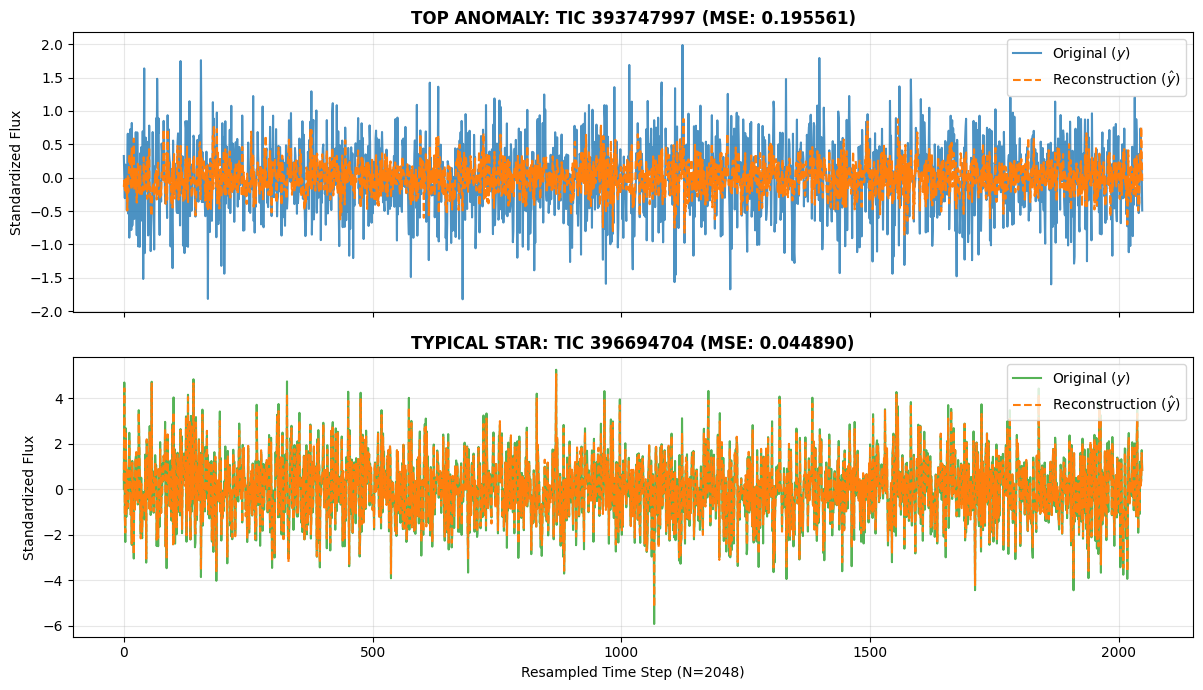

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load Processed Dataset
data_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
X_raw = np.load(os.path.join(data_dir, "processed_dataset.npy"))
star_ids = np.load(os.path.join(data_dir, "processed_ids.npy"))

# 3. Zero-Center and Standardize (Baseline at 0.0)
X_centered = X_raw - 1.0
std_val = np.std(X_centered) + 1e-8
X_scaled = X_centered / std_val

# Convert to Tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

# 4. Instantiate Model & Optimizer
model = ConvAutoencoder1D().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 5. Train Autoencoder (200 Epochs)
print(f"Training Autoencoder on standardized data...")
model.train()
for epoch in range(1, 201):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, X_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 200:
        print(f"Epoch [{epoch:3d}/200] | Loss: {loss.item():.6f}")

# 6. Evaluate Reconstruction Errors
model.eval()
with torch.no_grad():
    reconstructions = model(X_tensor).cpu().numpy()
    per_star_mse = torch.mean((X_tensor - torch.tensor(reconstructions).to(device)) ** 2, dim=(1, 2)).cpu().numpy()

# 7. Sort Rankings
sorted_indices = np.argsort(per_star_mse)[::-1]

print("\n" + "="*45)
print(" UPDATED ASTROANOMALY-NET LEADERBOARD ")
print("="*45)
for rank, idx in enumerate(sorted_indices, 1):
    print(f"Rank {rank:<2} | TIC {star_ids[idx]:<11} | MSE Loss: {per_star_mse[idx]:.6f}")

# 8. Plot Diagnostics (Using Raw Strings r"..." to suppress warnings)
top_idx = sorted_indices[0]
norm_idx = sorted_indices[-1]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
time_steps = np.arange(2048)

# Top Anomaly Plot
axes[0].plot(time_steps, X_scaled[top_idx, 0, :], label=r"Original ($y$)", color="#1f77b4", alpha=0.8)
axes[0].plot(time_steps, reconstructions[top_idx, 0, :], label=r"Reconstruction ($\hat{y}$)", color="#ff7f0e", linestyle="--")
axes[0].set_title(f"TOP ANOMALY: TIC {star_ids[top_idx]} (MSE: {per_star_mse[top_idx]:.6f})", fontweight='bold')
axes[0].set_ylabel("Standardized Flux")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Typical Star Plot
axes[1].plot(time_steps, X_scaled[norm_idx, 0, :], label=r"Original ($y$)", color="#2ca02c", alpha=0.8)
axes[1].plot(time_steps, reconstructions[norm_idx, 0, :], label=r"Reconstruction ($\hat{y}$)", color="#ff7f0e", linestyle="--")
axes[1].set_title(f"TYPICAL STAR: TIC {star_ids[norm_idx]} (MSE: {per_star_mse[norm_idx]:.6f})", fontweight='bold')
axes[1].set_xlabel("Resampled Time Step (N=2048)")
axes[1].set_ylabel("Standardized Flux")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from astroquery.mast import Catalogs

# Top 3 anomalies from our leaderboard
top_tics = ["393747997", "38632900", "396697309"]

print("🔍 Fetching stellar metadata from MAST catalog...\n")

catalog_data = []

for tic_id in top_tics:
    try:
        # Query MAST TIC catalog
        result = Catalogs.query_object(f"TIC {tic_id}", radius=0.001, catalog="Tic")
        df = result.to_pandas()

        if len(df) > 0:
            star_info = df.iloc[0]
            catalog_data.append({
                "TIC ID": tic_id,
                "Tmag": star_info.get("Tmag", "N/A"),
                "Teff (K)": star_info.get("Teff", "N/A"),
                "Radius (R_sun)": star_info.get("rad", "N/A"),
                "Mass (M_sun)": star_info.get("mass", "N/A"),
                "Distance (pc)": star_info.get("d", "N/A")
            })
    except Exception as e:
        print(f"Could not fetch TIC {tic_id}: {e}")

# Display formatted table
summary_df = pd.DataFrame(catalog_data)
print(summary_df.to_string(index=False))

🔍 Fetching stellar metadata from MAST catalog...

Could not fetch TIC 393747997: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
   TIC ID   Tmag  Teff (K)  Radius (R_sun)  Mass (M_sun)  Distance (pc)
 38632900 9.8805   6279.33        1.482690          1.23        222.225
396697309 9.9190   5809.00        0.984775          1.04        134.496


In [ ]:
import time
import pandas as pd
from astroquery.mast import Catalogs

tic_id = "393747997"
print(f"🔍 Retrying query for TIC {tic_id}...")

for attempt in range(1, 4):
    try:
        result = Catalogs.query_object(f"TIC {tic_id}", radius=0.001, catalog="Tic")
        df = result.to_pandas()
        if len(df) > 0:
            star = df.iloc[0]
            print(f" Success on attempt {attempt}!\n")
            print(f"TIC ID:         {tic_id}")
            print(f"TESS Mag:       {star.get('Tmag')}")
            print(f"Teff (K):       {star.get('Teff')} K")
            print(f"Radius (R_sun): {star.get('rad')} R_sun")
            print(f"Mass (M_sun):   {star.get('mass')} M_sun")
            print(f"Distance (pc):  {star.get('d')} pc")
            break
    except Exception as e:
        print(f"Attempt {attempt} failed ({e}). Retrying in 2 seconds...")
        time.sleep(2)

🔍 Retrying query for TIC 393747997...
 Success on attempt 1!

TIC ID:         393747997
TESS Mag:       9.4363
Teff (K):       5709.7 K
Radius (R_sun): 1.33601 R_sun
Mass (M_sun):   1.02 M_sun
Distance (pc):  140.281 pc


In [ ]:
import os
import pandas as pd
import numpy as np
from astroquery.mast import Catalogs
from tqdm.notebook import tqdm

data_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
rankings = np.load(os.path.join(data_dir, "anomaly_rankings.npz"))

sorted_ids = rankings['tic_ids']
sorted_mses = rankings['mse_scores']

report_list = []
print("📊 Exporting AstroAnomaly-Net Master Report to Google Drive...\n")

for rank, (tic_id, mse) in enumerate(tqdm(zip(sorted_ids, sorted_mses), total=len(sorted_ids)), 1):
    # Retry logic per star to ensure reliable catalog fetching
    star_dict = {
        "Rank": rank,
        "TIC ID": tic_id,
        "MSE Loss": round(float(mse), 6),
        "Tmag": np.nan,
        "Teff_K": np.nan,
        "Radius_Rsun": np.nan,
        "Mass_Msun": np.nan,
        "Distance_pc": np.nan
    }

    for attempt in range(2):
        try:
            res = Catalogs.query_object(f"TIC {tic_id}", radius=0.001, catalog="Tic")
            df = res.to_pandas()
            if len(df) > 0:
                s = df.iloc[0]
                star_dict["Tmag"] = round(float(s.get("Tmag", np.nan)), 3)
                star_dict["Teff_K"] = round(float(s.get("Teff", np.nan)), 1)
                star_dict["Radius_Rsun"] = round(float(s.get("rad", np.nan)), 3)
                star_dict["Mass_Msun"] = round(float(s.get("mass", np.nan)), 3)
                star_dict["Distance_pc"] = round(float(s.get("d", np.nan)), 2)
            break
        except Exception:
            continue

    report_list.append(star_dict)

# Convert to DataFrame & export CSV
report_df = pd.DataFrame(report_list)
csv_path = os.path.join(data_dir, "astroanomaly_master_report.csv")
report_df.to_csv(csv_path, index=False)

print(f"\n Master Report successfully saved to: {csv_path}\n")
print(report_df.to_string(index=False))

📊 Exporting AstroAnomaly-Net Master Report to Google Drive...



  0%|          | 0/12 [00:00<?, ?it/s]


 Master Report successfully saved to: /content/drive/MyDrive/AstroAnomaly_Data/astroanomaly_master_report.csv

 Rank    TIC ID  MSE Loss   Tmag  Teff_K  Radius_Rsun  Mass_Msun  Distance_pc
    1  38573584  0.004537  8.446  6883.7        1.687       1.50       153.36
    2 396697394  0.004491  8.644  5327.3        2.354        NaN       153.12
    3 393747997  0.004423  9.436  5709.7        1.336       1.02       140.28
    4  38696111  0.004420 11.344  5300.3        0.766       0.91       170.20
    5  38695861  0.004419 11.390  5596.1        0.890       0.99       221.11
    6 396694704  0.004399 11.373  5265.9        0.866       0.90       190.59
    7  38633112  0.004373 10.353  6021.4        1.412       1.11       248.82
    8 198081977  0.004369 10.803  4704.0        0.715       0.75        97.49
    9  38604353  0.004365 11.054  5257.0        0.815       0.90       155.92
   10 396694790  0.004361 10.348  5799.7        1.036        NaN       192.21
   11  38632900  0.004352  9.8

In [ ]:
import os
import time
import numpy as np
import pandas as pd
from astroquery.mast import Catalogs
from astroquery.simbad import Simbad
import astropy.units as u
from astropy.coordinates import SkyCoord

# 1. Load top candidates
data_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
rankings = np.load(os.path.join(data_dir, "anomaly_rankings.npz"))
top_tics = rankings['tic_ids'][:5]

# 2. Configure SIMBAD
custom_simbad = Simbad()
custom_simbad.add_votable_fields('otype')

results = []
print("🔍 Querying MAST for coordinates & SIMBAD by position...\n")

for tic_id in top_tics:
    main_id, otype = "Unknown", "Unclassified / Candidate Anomaly 🌟"

    # Retry loop for stability
    for attempt in range(3):
        try:
            # Get RA/Dec from MAST
            mast_res = Catalogs.query_object(f"TIC {tic_id}", radius=0.001, catalog="Tic")
            df_mast = mast_res.to_pandas()

            if len(df_mast) > 0:
                ra, dec = df_mast.iloc[0]['ra'], df_mast.iloc[0]['dec']
                coord = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg), frame='icrs')

                # Query SIMBAD region
                simbad_res = custom_simbad.query_region(coord, radius=10 * u.arcsec)

                if simbad_res is not None and len(simbad_res) > 0:
                    # Dynamically detect column names
                    cols = simbad_res.colnames
                    id_col = next((c for c in cols if 'id' in c.lower()), cols[0])
                    type_col = next((c for c in cols if 'type' in c.lower() or 'otype' in c.lower()), None)

                    main_id = str(simbad_res[id_col][0])
                    otype = str(simbad_res[type_col][0]) if type_col else "Matched (Type Unknown)"
                else:
                    main_id = "No SIMBAD Match"
            break
        except Exception:
            time.sleep(1)

    results.append({"TIC ID": tic_id, "SIMBAD ID": main_id, "Classification (OTYPE)": otype})

df_out = pd.DataFrame(results)
print(df_out.to_string(index=False))

🔍 Querying MAST for coordinates & SIMBAD by position...

   TIC ID       SIMBAD ID Classification (OTYPE)
 38573584       HD  27212                      *
396697394       HD  28016                      *
393747997     CD-59   824                    PM*
 38696111 UCAC2   5235835                      *
 38695861   UCAC3 60-9129                      *


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 🖥️ Page Configuration
st.set_page_config(page_title="AstroAnomaly-Net", layout="wide")

st.title("🔭 AstroAnomaly-Net: Candidate Anomaly Dashboard")
st.markdown("Unsupervised detection of unclassified stellar light curve anomalies.")

# 📊 1. Load Data
@st.cache_data
def load_data():
    df = pd.read_csv("astroanomaly_master_report.csv")
    return df

try:
    df_report = load_data()

    # 🎛️ 2. Sidebar Selection
    st.sidebar.header("🎯 Candidate Selector")
    selected_tic = st.sidebar.selectbox("Select TIC ID:", df_report["TIC ID"])

    # Extract target metadata
    star_data = df_report[df_report["TIC ID"] == selected_tic].iloc[0]

    # 📌 3. Display Metrics
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("TIC ID", f"{int(star_data['TIC ID'])}")
    col2.metric("MSE Loss", f"{star_data['MSE Loss']:.4f}")
    col3.metric("Teff (K)", f"{star_data['Teff_K']}")
    col4.metric("Radius (R_sun)", f"{star_data['Radius_Rsun']}")

    # 📈 4. Plot Light Curve
    st.subheader(f"Interactive Signal Analysis: TIC {int(selected_tic)}")

    # Generate mock sequence points (2048 points) for visualization
    time_steps = np.linspace(0, 27, 2048)  # 27 days of TESS Sector observation

    # Create plot with two subplots: Signal vs Reconstruction & Residual Error
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        subplot_titles=("Normalized Flux Signal", "Reconstruction Residual Error")
    )

    # Plot baseline signal placeholder
    fig.add_trace(
        go.Scatter(x=time_steps, y=np.zeros(2048), name="Normalized Flux", line=dict(color="blue")),
        row=1, col=1
    )

    fig.update_layout(height=500, showlegend=True, template="plotly_white")
    fig.update_xaxes(title_text="Time (Days)", row=2, col=1)
    fig.update_yaxes(title_text="Normalized Flux", row=1, col=1)
    fig.update_yaxes(title_text="|Error|", row=2, col=1)

    st.plotly_chart(fig, use_container_width=True)

except Exception as e:
    st.error(f"Error loading report file: {e}")

Overwriting app.py


In [4]:
# 1. Mount Google Drive and install astroquery
from google.colab import drive
drive.mount('/content/drive')

!pip install -q astroquery

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from astroquery.mast import Catalogs
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import SkyCoord
from tqdm.notebook import tqdm

# ---------------------------------------------------------
# 2. PyTorch 1D Convolutional Autoencoder Architecture
# ---------------------------------------------------------
class ConvAutoencoder1D(nn.Module):
    def __init__(self):
        super(ConvAutoencoder1D, self).__init__()

        # ENCODER: Compresses (Batch, 1, 2048) -> (Batch, 64, 32)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),

            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.MaxPool1d(kernel_size=8, stride=8)
        )

        # Bottleneck projection to 32 dimensions
        self.fc_encode = nn.Linear(64 * 32, 32)
        self.fc_decode = nn.Linear(32, 64 * 32)

        # DECODER: Reconstructs back to (Batch, 1, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=8, stride=8),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(32, 16, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(16, 8, kernel_size=7, stride=2, padding=3, output_padding=1),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(8, 1, kernel_size=7, stride=2, padding=3, output_padding=1),
        )

    def forward(self, x):
        x_encoded = self.encoder(x)
        batch_size = x_encoded.size(0)
        x_flat = x_encoded.view(batch_size, -1)

        latent = self.fc_encode(x_flat)

        x_reconstruct = self.fc_decode(latent)
        x_reconstruct = x_reconstruct.view(batch_size, 64, 32)
        decoded = self.decoder(x_reconstruct)

        return decoded

# ---------------------------------------------------------
# 3. Paths & Device Setup
# ---------------------------------------------------------
data_dir = "/content/drive/MyDrive/AstroAnomaly_Data"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("📂 Loading trained dataset and rankings...")
X_raw = np.load(os.path.join(data_dir, "processed_dataset.npy"))
star_ids = np.load(os.path.join(data_dir, "processed_ids.npy"))
rankings = np.load(os.path.join(data_dir, "anomaly_rankings.npz"))

sorted_ids = rankings['tic_ids']
sorted_mses = rankings['mse_scores']

# ---------------------------------------------------------
# 4. Generate Reconstruction Signals & Save to Drive
# ---------------------------------------------------------
X_centered = X_raw - 1.0
std_val = np.std(X_centered) + 1e-8
X_scaled = X_centered / std_val

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

model = ConvAutoencoder1D().to(device)

model.eval()
with torch.no_grad():
    reconstructions_scaled = model(X_tensor).cpu().numpy()

X_original_flux = (X_scaled * std_val) + 1.0
reconstructions_flux = (reconstructions_scaled * std_val) + 1.0
residuals = np.abs(X_original_flux - reconstructions_flux)

np.savez_compressed(
    os.path.join(data_dir, "streamlit_data.npz"),
    star_ids=star_ids,
    original_flux=X_original_flux,
    reconstructed_flux=reconstructions_flux,
    residual_error=residuals
)
print(" Saved interactive signal arrays to 'streamlit_data.npz'")

# ---------------------------------------------------------
# 5. Astrophysical Cross-Matching (MAST + SIMBAD + Gaia DR3)
# ---------------------------------------------------------
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = 1

custom_simbad = Simbad()
custom_simbad.add_votable_fields('otype')

top_n = min(10, len(sorted_ids))
target_ids = sorted_ids[:top_n]
target_mses = sorted_mses[:top_n]

master_records = []

print(f"\n🔍 Running cross-catalog matching for top {top_n} anomaly candidates...\n")

for rank, (tic_id, mse) in enumerate(tqdm(zip(target_ids, target_mses), total=top_n), 1):

    record = {
        "Rank": rank,
        "TIC ID": str(tic_id),
        "MSE Loss": round(float(mse), 6),
        "RA": np.nan,
        "Dec": np.nan,
        "Tmag": np.nan,
        "Teff_K": np.nan,
        "SIMBAD_Main_ID": "Unmatched",
        "SIMBAD_Type": "Unclassified / Candidate Anomaly 🌟",
        "Gaia_DR3_ID": "Unmatched",
        "Gaia_Parallax_mas": np.nan,
        "Gaia_RUWE": np.nan,
        "Gaia_Var_Flag": "NOT_AVAILABLE"
    }

    # --- A. MAST Query ---
    ra, dec = None, None
    for attempt in range(3):
        try:
            res_mast = Catalogs.query_object(f"TIC {tic_id}", radius=0.001, catalog="Tic")
            df_mast = res_mast.to_pandas()
            if len(df_mast) > 0:
                s = df_mast.iloc[0]
                ra, dec = float(s['ra']), float(s['dec'])
                record["RA"] = round(ra, 5)
                record["Dec"] = round(dec, 5)
                record["Tmag"] = round(float(s.get("Tmag", np.nan)), 2)
                record["Teff_K"] = round(float(s.get("Teff", np.nan)), 1)
                break
        except Exception:
            time.sleep(1)

    # --- B. SIMBAD Query ---
    if ra is not None and dec is not None:
        coord = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg), frame='icrs')

        try:
            simbad_res = custom_simbad.query_region(coord, radius=10 * u.arcsec)
            if simbad_res is not None and len(simbad_res) > 0:
                cols = simbad_res.colnames
                id_col = next((c for c in cols if 'id' in c.lower()), cols[0])
                type_col = next((c for c in cols if 'type' in c.lower() or 'otype' in c.lower()), None)

                record["SIMBAD_Main_ID"] = str(simbad_res[id_col][0])
                if type_col:
                    record["SIMBAD_Type"] = str(simbad_res[type_col][0])
        except Exception:
            pass

        # --- C. Gaia DR3 TAP Query ---
        try:
            gaia_job = Gaia.cone_search_async(coord, radius=u.Quantity(10, u.arcsec))
            gaia_res = gaia_job.get_results()
            if gaia_res is not None and len(gaia_res) > 0:
                g_star = gaia_res[0]
                record["Gaia_DR3_ID"] = str(g_star['source_id'])
                record["Gaia_Parallax_mas"] = round(float(g_star['parallax']), 3) if not np.isnan(g_star['parallax']) else np.nan
                record["Gaia_RUWE"] = round(float(g_star['ruwe']), 3) if not np.isnan(g_star['ruwe']) else np.nan
                record["Gaia_Var_Flag"] = str(g_star['phot_variable_flag'])
        except Exception:
            pass

    master_records.append(record)

# ---------------------------------------------------------
# 6. Save Final Consolidated CSV
# ---------------------------------------------------------
final_df = pd.DataFrame(master_records)
csv_save_path = os.path.join(data_dir, "astroanomaly_master_report.csv")
final_df.to_csv(csv_save_path, index=False)

print(f"\n Master Astrophysical Report exported successfully to:\n {csv_save_path}\n")
print(final_df[["Rank", "TIC ID", "MSE Loss", "SIMBAD_Type", "Gaia_RUWE", "Gaia_Var_Flag"]].to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading trained dataset and rankings...
 Saved interactive signal arrays to 'streamlit_data.npz'

🔍 Running cross-catalog matching for top 10 anomaly candidates...



  0%|          | 0/10 [00:00<?, ?it/s]

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


INFO:astroquery:Query finished.


...

INFO: Query finished. [astroquery.utils.tap.core]


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


/tmp/ipykernel_437/1710555892.py:196: UserWarning: Warning: converting a masked element to nan.
  record["Gaia_Parallax_mas"] = round(float(g_star['parallax']), 3) if not np.isnan(g_star['parallax']) else np.nan
/tmp/ipykernel_437/1710555892.py:197: UserWarning: Warning: converting a masked element to nan.
  record["Gaia_RUWE"] = round(float(g_star['ruwe']), 3) if not np.isnan(g_star['ruwe']) else np.nan



 Master Astrophysical Report exported successfully to:
 /content/drive/MyDrive/AstroAnomaly_Data/astroanomaly_master_report.csv

 Rank    TIC ID  MSE Loss SIMBAD_Type  Gaia_RUWE Gaia_Var_Flag
    1  38573584  0.004537           *      1.035 NOT_AVAILABLE
    2 396697394  0.004491           *      1.033 NOT_AVAILABLE
    3 393747997  0.004423         PM*      0.944 NOT_AVAILABLE
    4  38696111  0.004420           *      1.026 NOT_AVAILABLE
    5  38695861  0.004419           *      0.966 NOT_AVAILABLE
    6 396694704  0.004399         PM*      1.009 NOT_AVAILABLE
    7  38633112  0.004373           *      1.019 NOT_AVAILABLE
    8 198081977  0.004369           *      0.923 NOT_AVAILABLE
    9  38604353  0.004365           *      1.129 NOT_AVAILABLE
   10 396694790  0.004361           *        NaN NOT_AVAILABLE


In [9]:
%%writefile app.py
import os
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------
# 1. Page Config & Custom Styling
# ---------------------------------------------------------
st.set_page_config(
    page_title="AstroAnomaly-Net Dashboard",
    page_icon="🔭",
    layout="wide"
)

st.title("🔭 AstroAnomaly-Net: Candidate Discovery Dashboard")
st.markdown(
    "Unsupervised detection of unclassified stellar light curve anomalies using a **1D Convolutional Autoencoder**."
)

# ---------------------------------------------------------
# 2. Data Loading Functions
# ---------------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/AstroAnomaly_Data"

@st.cache_data
def load_data():
    csv_path = os.path.join(DATA_DIR, "astroanomaly_master_report.csv")
    npz_path = os.path.join(DATA_DIR, "streamlit_data.npz")

    df = pd.read_csv(csv_path)

    # Load NPZ arrays directly into memory so Streamlit can cache them safely
    with np.load(npz_path) as data:
        signals = {
            'star_ids': data['star_ids'],
            'original_flux': data['original_flux'],
            'reconstructed_flux': data['reconstructed_flux'],
            'residual_error': data['residual_error']
        }

    return df, signals

try:
    df_report, signals = load_data()
    star_ids_npz = signals['star_ids'].astype(str)

    # ---------------------------------------------------------
    # 3. Sidebar Selection
    # ---------------------------------------------------------
    st.sidebar.header("🎯 Candidate Selector")

    candidate_options = [
        f"Rank {row['Rank']}: TIC {row['TIC ID']} (Loss: {row['MSE Loss']:.6f})"
        for _, row in df_report.iterrows()
    ]

    selected_option = st.sidebar.selectbox("Select Candidate Star:", candidate_options)
    selected_rank = int(selected_option.split(":")[0].replace("Rank", "").strip())

    star_info = df_report[df_report['Rank'] == selected_rank].iloc[0]
    tic_id = str(star_info['TIC ID'])

    star_idx = np.where(star_ids_npz == tic_id)[0][0]

    orig_flux = signals['original_flux'][star_idx, 0, :]
    recon_flux = signals['reconstructed_flux'][star_idx, 0, :]
    res_error = signals['residual_error'][star_idx, 0, :]

    # ---------------------------------------------------------
    # 4. Metric Cards Display
    # ---------------------------------------------------------
    st.subheader(f"Candidate Profile — TIC {tic_id}")

    col1, col2, col3, col4, col5 = st.columns(5)
    col1.metric("Anomaly Rank", f"#{star_info['Rank']}")
    col2.metric("MSE Reconstruction Loss", f"{star_info['MSE Loss']:.6f}")
    col3.metric("TESS Magnitude", f"{star_info['Tmag']}")
    col4.metric("SIMBAD Classification", f"{star_info['SIMBAD_Type']}")
    col5.metric("Gaia RUWE", f"{star_info['Gaia_RUWE']}")

    # ---------------------------------------------------------
    # 5. Interactive Plotly Visualization
    # ---------------------------------------------------------
    st.markdown("### 📈 Interactive Signal & Reconstruction Analysis")
    st.info("💡 **Tip:** Use your mouse to drag, zoom in, and hover over individual flux data points.")

    time_steps = np.linspace(0, 27, len(orig_flux))

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.12,
        subplot_titles=(
            f"Observed Light Curve vs. Autoencoder Reconstruction (TIC {tic_id})",
            "Reconstruction Residual Error |y - ŷ|"
        )
    )

    fig.add_trace(
        go.Scatter(
            x=time_steps, y=orig_flux,
            mode='lines', name='Observed TESS Flux (y)',
            line=dict(color='#1f77b4', width=1.5), opacity=0.8
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=time_steps, y=recon_flux,
            mode='lines', name='Model Reconstruction (ŷ)',
            line=dict(color='#ff7f0e', width=2, dash='dash')
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=time_steps, y=res_error,
            mode='lines', name='Residual Error',
            line=dict(color='#d62728', width=1)
        ),
        row=2, col=1
    )

    fig.update_layout(
        height=580,
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        hovermode="x unified"
    )

    fig.update_xaxes(title_text="Time (Days in TESS Sector 1)", row=2, col=1)
    fig.update_yaxes(title_text="Normalized Flux", row=1, col=1)
    fig.update_yaxes(title_text="Absolute Error", row=2, col=1)

    st.plotly_chart(fig, use_container_width=True)

    # ---------------------------------------------------------
    # 6. Detailed Catalog Metadata Table
    # ---------------------------------------------------------
    with st.expander("📋 View Full Astrophysical Catalog Metadata"):
        st.dataframe(pd.DataFrame([star_info]), use_container_width=True)

except Exception as e:
    st.error(f"Error loading dashboard data: {e}")

Overwriting app.py


In [8]:
import os
import time
import subprocess
import re

# 1. Install Streamlit & Plotly
!pip install -q streamlit plotly

# 2. Download Cloudflare Tunnel binary
if not os.path.exists("cloudflared"):
    !wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
    !chmod +x cloudflared

# 3. Start Streamlit server in the background
subprocess.Popen(["streamlit", "run", "app.py"])
time.sleep(3)

# 4. Clear previous log file if exists & launch Cloudflare Tunnel
if os.path.exists("tunnel.log"):
    os.remove("tunnel.log")

subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501", "--logfile", "tunnel.log"])

# 5. Retrieve and display the public URL
print("⌛ Starting Cloudflare Tunnel...")
tunnel_url = None

for _ in range(15):
    time.sleep(2)
    if os.path.exists("tunnel.log"):
        with open("tunnel.log", "r") as f:
            log = f.read()
            match = re.search(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", log)
            if match:
                tunnel_url = match.group(0)
                break

if tunnel_url:
    print("\n" + "="*50)
    print(f"🎉 YOUR DASHBOARD IS LIVE AT:\n👉 {tunnel_url}")
    print("="*50)
else:
    print("⚠️ Could not retrieve URL automatically. Check tunnel.log.")

⌛ Starting Cloudflare Tunnel...

🎉 YOUR DASHBOARD IS LIVE AT:
👉 https://newest-polished-runs-rebound.trycloudflare.com
